# Dynamic AC Generator With a Balanced Resistive Load

This notebook simulates a simplified isolated three-phase AC generator feeding a balanced star-connected resistive load. The goal is to show how an active-power disturbance changes rotor speed and frequency, and how an isochronous PI governor restores the active-power balance.

The model is intentionally compact and didactic. It does not use external power-system simulation libraries. The mechanical dynamics are implemented directly from differential equations, and the three-phase electrical waveforms are reconstructed from the rotor electrical angle.

Main ideas:

- Frequency is proportional to rotor speed.
- A sudden load increase makes electrical power exceed mechanical power.
- Inertia slows the frequency decline but does not remove the imbalance.
- The governor increases mechanical power through the prime mover.
- Integral action eliminates the steady-state speed error for this simplified model.

## Physical Model

The generator is represented by a constant-voltage sinusoidal source whose frequency follows the rotor electrical speed. The mechanical side is modeled with the per-unit swing equation:

\[
\frac{d\omega_{\mathrm{pu}}}{dt}
=
\frac{P_{m,\mathrm{pu}} - P_{e,\mathrm{pu}} - D(\omega_{\mathrm{pu}} - 1)}{2H}
\]

The instantaneous frequency is:

\[
f(t) = f_{\mathrm{nom}}\omega_{\mathrm{pu}}(t)
\]

The electrical rotor angle is:

\[
\frac{d\theta}{dt} = \omega_{\mathrm{nom}}\omega_{\mathrm{pu}}
\quad\text{with}\quad
\omega_{\mathrm{nom}} = 2\pi f_{\mathrm{nom}}
\]

The load is a balanced three-phase resistor, so the total instantaneous three-phase power is approximately constant even though each phase voltage and current is sinusoidal.

## Imports and Numerical Settings

The notebook uses NumPy for array calculations, SciPy for ODE integration, Matplotlib for figures, Pandas for tabular results, and pathlib for reproducible output paths.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Callable

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from scipy.integrate import solve_ivp


FloatArray = NDArray[np.float64]

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Editable Simulation Configuration

All main inputs are collected in the `SimulationConfig` dataclass. Mechanical power and electrical power are represented in per unit. Voltages, currents, and resistances are represented in SI units.

The default case uses a 0.50 pu to 0.80 pu load step at 2.0 s. The strict settling-time tolerance is 0.01 Hz. With the 10 s demonstration window, the PI response may be close to 60 Hz before it has permanently entered this very tight band.

In [2]:
@dataclass(frozen=True)
class SimulationConfig:
    """Configuration parameters for the isolated generator simulation."""

    F_NOM_HZ: float = 60.0
    V_LL_RMS: float = 400.0
    S_BASE_VA: float = 100_000.0

    H: float = 3.0
    D: float = 0.0

    KP: float = 5.0
    KI: float = 2.0
    T_M: float = 0.2

    P_M_MIN_PU: float = 0.0
    P_M_MAX_PU: float = 1.2

    INITIAL_LOAD_PU: float = 0.50
    FINAL_LOAD_PU: float = 0.80

    LOAD_STEP_TIME_S: float = 2.0
    SIMULATION_TIME_S: float = 10.0
    FREQUENCY_TOLERANCE_HZ: float = 0.01

    DYNAMIC_SAMPLE_STEP_S: float = 0.002
    SLOW_MAX_STEP_S: float = 0.01
    WAVEFORM_SAMPLE_STEP_S: float = 0.00005
    WAVEFORM_WINDOW_S: float = 0.12

    RELATIVE_TOLERANCE: float = 1e-9
    ABSOLUTE_TOLERANCE: float = 1e-11

    def __post_init__(self) -> None:
        """Validate configuration values with clear error messages."""
        if self.F_NOM_HZ <= 0.0:
            raise ValueError("Nominal frequency must be positive.")
        if self.V_LL_RMS <= 0.0:
            raise ValueError("Nominal line-to-line RMS voltage must be positive.")
        if self.S_BASE_VA <= 0.0:
            raise ValueError("Base apparent power must be positive.")
        if self.H <= 0.0:
            raise ValueError("Inertia constant H must be positive.")
        if self.D < 0.0:
            raise ValueError("Damping coefficient D cannot be negative.")
        if self.KP < 0.0:
            raise ValueError("Governor proportional gain KP cannot be negative.")
        if self.KI < 0.0:
            raise ValueError("Governor integral gain KI cannot be negative.")
        if self.T_M <= 0.0:
            raise ValueError("Prime-mover time constant T_M must be positive.")
        if self.P_M_MIN_PU >= self.P_M_MAX_PU:
            raise ValueError("Mechanical power minimum must be lower than maximum.")
        if self.INITIAL_LOAD_PU <= 0.0:
            raise ValueError("Initial load power must be positive.")
        if self.FINAL_LOAD_PU <= 0.0:
            raise ValueError("Final load power must be positive.")
        if not (self.P_M_MIN_PU <= self.INITIAL_LOAD_PU <= self.P_M_MAX_PU):
            raise ValueError("Initial load must be inside the mechanical power limits.")
        if self.FINAL_LOAD_PU > self.P_M_MAX_PU:
            raise ValueError("Final load must not exceed the maximum mechanical power for this recovery case.")
        if not (0.0 < self.LOAD_STEP_TIME_S < self.SIMULATION_TIME_S):
            raise ValueError("Load step time must be greater than zero and lower than the simulation time.")
        if self.FREQUENCY_TOLERANCE_HZ <= 0.0:
            raise ValueError("Frequency tolerance must be positive.")
        if self.DYNAMIC_SAMPLE_STEP_S <= 0.0:
            raise ValueError("Dynamic sample step must be positive.")
        if self.SLOW_MAX_STEP_S <= 0.0:
            raise ValueError("Maximum ODE step must be positive.")
        if self.WAVEFORM_SAMPLE_STEP_S <= 0.0:
            raise ValueError("Waveform sample step must be positive.")
        if self.WAVEFORM_WINDOW_S <= 0.0:
            raise ValueError("Waveform window must be positive.")

    @property
    def omega_nominal_rad_per_s(self) -> float:
        """Return the nominal electrical angular frequency in rad/s."""
        return 2.0 * math.pi * self.F_NOM_HZ

    @property
    def phase_voltage_rms(self) -> float:
        """Return the nominal phase-to-neutral RMS voltage."""
        return self.V_LL_RMS / math.sqrt(3.0)

    @property
    def initial_power_w(self) -> float:
        """Return the initial three-phase active power in watts."""
        return self.INITIAL_LOAD_PU * self.S_BASE_VA

    @property
    def final_power_w(self) -> float:
        """Return the final three-phase active power in watts."""
        return self.FINAL_LOAD_PU * self.S_BASE_VA

    @property
    def initial_resistance_ohm(self) -> float:
        """Return the initial phase resistance in ohms."""
        return 3.0 * self.phase_voltage_rms**2 / self.initial_power_w

    @property
    def final_resistance_ohm(self) -> float:
        """Return the final phase resistance in ohms."""
        return 3.0 * self.phase_voltage_rms**2 / self.final_power_w


config = SimulationConfig()
config

SimulationConfig(F_NOM_HZ=60.0, V_LL_RMS=400.0, S_BASE_VA=100000.0, H=3.0, D=0.0, KP=5.0, KI=2.0, T_M=0.2, P_M_MIN_PU=0.0, P_M_MAX_PU=1.2, INITIAL_LOAD_PU=0.5, FINAL_LOAD_PU=0.8, LOAD_STEP_TIME_S=2.0, SIMULATION_TIME_S=10.0, FREQUENCY_TOLERANCE_HZ=0.01, DYNAMIC_SAMPLE_STEP_S=0.002, SLOW_MAX_STEP_S=0.01, WAVEFORM_SAMPLE_STEP_S=5e-05, WAVEFORM_WINDOW_S=0.12, RELATIVE_TOLERANCE=1e-09, ABSOLUTE_TOLERANCE=1e-11)

## Load Model

For a balanced star-connected resistive load:

\[
R = \frac{3V_{\mathrm{ph,rms}}^2}{P}
\]

At the load-step time, the resistance changes instantaneously. Since the excitation system is assumed ideal, the phase RMS voltage is held constant and the three-phase active power is determined directly by the selected resistance.

In [3]:
class ResistiveLoad:
    """Balanced star-connected three-phase resistive load."""

    def __init__(self, config: SimulationConfig) -> None:
        self.config = config

    def active_power_w(self, load_power_pu: float | FloatArray) -> float | FloatArray:
        """Convert load active power from per unit to watts."""
        return load_power_pu * self.config.S_BASE_VA

    def phase_resistance_ohm(self, load_power_pu: float | FloatArray) -> float | FloatArray:
        """Calculate phase resistance for the requested per-unit active power."""
        active_power_w = self.active_power_w(load_power_pu)
        return 3.0 * self.config.phase_voltage_rms**2 / active_power_w

    def load_power_pu_at(self, time_s: float | FloatArray) -> float | FloatArray:
        """Return the load active power in per unit at a time or array of times."""
        time_array = np.asarray(time_s, dtype=float)
        load_values = np.where(
            time_array < self.config.LOAD_STEP_TIME_S,
            self.config.INITIAL_LOAD_PU,
            self.config.FINAL_LOAD_PU,
        )
        if np.isscalar(time_s):
            return float(load_values)
        return load_values.astype(float)

    def resistance_at(self, time_s: float | FloatArray) -> float | FloatArray:
        """Return the phase resistance in ohms at a time or array of times."""
        return self.phase_resistance_ohm(self.load_power_pu_at(time_s))

    def electrical_power_pu_at(self, time_s: float | FloatArray) -> float | FloatArray:
        """Return the three-phase electrical power in per unit."""
        resistance_ohm = self.resistance_at(time_s)
        active_power_w = 3.0 * self.config.phase_voltage_rms**2 / resistance_ohm
        return active_power_w / self.config.S_BASE_VA


load = ResistiveLoad(config)

resistance_table = pd.DataFrame(
    [
        {
            "condition": "Initial load",
            "load_pu": config.INITIAL_LOAD_PU,
            "active_power_w": config.initial_power_w,
            "phase_resistance_ohm": config.initial_resistance_ohm,
        },
        {
            "condition": "Final load",
            "load_pu": config.FINAL_LOAD_PU,
            "active_power_w": config.final_power_w,
            "phase_resistance_ohm": config.final_resistance_ohm,
        },
    ]
)
resistance_table

,condition,load_pu,active_power_w,phase_resistance_ohm
0,Initial load,0.5,50000.0,3.2
1,Final load,0.8,80000.0,2.0


## Isochronous PI Governor and Prime Mover

The speed error is:

\[
e(t) = 1 - \omega_{\mathrm{pu}}(t)
\]

The PI state is:

\[
\frac{d\xi}{dt} = e(t)
\]

The mechanical power reference is:

\[
P_{m,\mathrm{ref}} = P_{m0} + K_p e + K_i\xi
\]

The reference is limited between minimum and maximum mechanical power. A simple conditional-integration anti-windup rule freezes the integrator when the reference is saturated and the current error would push it farther into saturation.

The prime mover is a first-order lag:

\[
T_m\frac{dP_m}{dt} = P_{m,\mathrm{ref}} - P_m
\]

In [4]:
class IsochronousGovernor:
    """PI speed governor with mechanical power limits and anti-windup."""

    def __init__(self, config: SimulationConfig) -> None:
        self.config = config

    def speed_error_pu(self, omega_pu: float | FloatArray) -> float | FloatArray:
        """Calculate the governor speed error."""
        return 1.0 - omega_pu

    def raw_reference_power_pu(
        self,
        omega_pu: float | FloatArray,
        integral_state: float | FloatArray,
    ) -> float | FloatArray:
        """Calculate the unlimited mechanical power reference in per unit."""
        error_pu = self.speed_error_pu(omega_pu)
        return self.config.INITIAL_LOAD_PU + self.config.KP * error_pu + self.config.KI * integral_state

    def limited_reference_power_pu(
        self,
        omega_pu: float | FloatArray,
        integral_state: float | FloatArray,
    ) -> float | FloatArray:
        """Apply mechanical power limits to the reference power."""
        raw_reference = self.raw_reference_power_pu(omega_pu, integral_state)
        limited_reference = np.clip(raw_reference, self.config.P_M_MIN_PU, self.config.P_M_MAX_PU)
        if np.isscalar(raw_reference):
            return float(limited_reference)
        return limited_reference.astype(float)

    def integral_derivative_pu(self, omega_pu: float, integral_state: float) -> float:
        """Calculate the anti-windup integral derivative."""
        error_pu = float(self.speed_error_pu(omega_pu))
        raw_reference = float(self.raw_reference_power_pu(omega_pu, integral_state))
        saturated_high = raw_reference >= self.config.P_M_MAX_PU and error_pu > 0.0
        saturated_low = raw_reference <= self.config.P_M_MIN_PU and error_pu < 0.0
        if saturated_high or saturated_low:
            return 0.0
        return error_pu

## Generator Dynamic Model

The dynamic state vector is:

\[
x =
\begin{bmatrix}
\omega_{\mathrm{pu}} &
\xi &
P_{m,\mathrm{pu}} &
\theta
\end{bmatrix}^{T}
\]

The slow mechanical states are solved with `solve_ivp`. The three-phase 60 Hz waveforms are reconstructed afterward from dense-state interpolation. This is efficient because the ODE solver does not need to resolve every sinusoidal voltage sample while computing the much slower mechanical dynamics.

In [5]:
class GeneratorModel:
    """Simplified synchronous generator model for active-power balance studies."""

    def __init__(
        self,
        config: SimulationConfig,
        load: ResistiveLoad,
        governor: IsochronousGovernor,
    ) -> None:
        self.config = config
        self.load = load
        self.governor = governor

    def state_derivatives(self, time_s: float, state: FloatArray) -> list[float]:
        """Return the derivatives of the dynamic state vector."""
        omega_pu = float(state[0])
        integral_state = float(state[1])
        mechanical_power_pu = float(state[2])

        electrical_power_pu = float(self.load.electrical_power_pu_at(time_s))
        reference_power_pu = float(
            self.governor.limited_reference_power_pu(omega_pu, integral_state)
        )
        integral_derivative_pu = self.governor.integral_derivative_pu(omega_pu, integral_state)

        speed_derivative_pu_per_s = (
            mechanical_power_pu
            - electrical_power_pu
            - self.config.D * (omega_pu - 1.0)
        ) / (2.0 * self.config.H)
        mechanical_power_derivative_pu_per_s = (
            reference_power_pu - mechanical_power_pu
        ) / self.config.T_M
        angle_derivative_rad_per_s = self.config.omega_nominal_rad_per_s * omega_pu

        return [
            speed_derivative_pu_per_s,
            integral_derivative_pu,
            mechanical_power_derivative_pu_per_s,
            angle_derivative_rad_per_s,
        ]

    def three_phase_voltages(self, theta_rad: FloatArray) -> tuple[FloatArray, FloatArray, FloatArray]:
        """Generate balanced phase-to-neutral voltages from rotor angle."""
        theta_wrapped_rad = np.mod(theta_rad + math.pi, 2.0 * math.pi) - math.pi
        voltage_peak = math.sqrt(2.0) * self.config.phase_voltage_rms
        voltage_a_v = voltage_peak * np.sin(theta_wrapped_rad)
        voltage_b_v = voltage_peak * np.sin(theta_wrapped_rad - 2.0 * math.pi / 3.0)
        voltage_c_v = voltage_peak * np.sin(theta_wrapped_rad + 2.0 * math.pi / 3.0)
        return voltage_a_v, voltage_b_v, voltage_c_v

    def phase_currents(
        self,
        voltage_a_v: FloatArray,
        voltage_b_v: FloatArray,
        voltage_c_v: FloatArray,
        resistance_ohm: FloatArray,
    ) -> tuple[FloatArray, FloatArray, FloatArray]:
        """Calculate phase currents for a balanced resistive load."""
        current_a_a = voltage_a_v / resistance_ohm
        current_b_a = voltage_b_v / resistance_ohm
        current_c_a = voltage_c_v / resistance_ohm
        return current_a_a, current_b_a, current_c_a

## Simulation Runner and Result Container

The load step is a discontinuity, so the simulation is solved in two segments: before and after the resistance change. The final state before the step is used as the initial state after the step.

In [6]:
@dataclass
class SimulationResults:
    """Container for dynamic simulation results and post-processing helpers."""

    config: SimulationConfig
    time_s: FloatArray
    omega_pu: FloatArray
    integral_state: FloatArray
    mechanical_power_pu: FloatArray
    rotor_angle_rad: FloatArray
    electrical_power_pu: FloatArray
    load_resistance_ohm: FloatArray
    mechanical_power_reference_pu: FloatArray
    state_sampler: Callable[[FloatArray], FloatArray] = field(repr=False)

    @property
    def frequency_hz(self) -> FloatArray:
        """Return generator frequency in hertz."""
        return self.config.F_NOM_HZ * self.omega_pu

    @property
    def frequency_error_hz(self) -> FloatArray:
        """Return nominal frequency minus actual frequency in hertz."""
        return self.config.F_NOM_HZ - self.frequency_hz

    def to_dataframe(self) -> pd.DataFrame:
        """Convert the dynamic simulation results to a Pandas DataFrame."""
        return pd.DataFrame(
            {
                "time_s": self.time_s,
                "frequency_hz": self.frequency_hz,
                "omega_pu": self.omega_pu,
                "frequency_error_hz": self.frequency_error_hz,
                "mechanical_power_pu": self.mechanical_power_pu,
                "electrical_power_pu": self.electrical_power_pu,
                "mechanical_power_reference_pu": self.mechanical_power_reference_pu,
                "load_resistance_ohm": self.load_resistance_ohm,
                "rotor_angle_rad": self.rotor_angle_rad,
                "governor_integral_state": self.integral_state,
            }
        )


class DynamicSimulation:
    """Solve the generator dynamics and reconstruct electrical waveforms."""

    def __init__(self, config: SimulationConfig) -> None:
        self.config = config
        self.load = ResistiveLoad(config)
        self.governor = IsochronousGovernor(config)
        self.model = GeneratorModel(config, self.load, self.governor)

    def _make_time_vector(self, start_s: float, end_s: float) -> FloatArray:
        """Create a deterministic time vector including the segment endpoint."""
        sample_count = int(math.floor((end_s - start_s) / self.config.DYNAMIC_SAMPLE_STEP_S)) + 1
        time_s = start_s + np.arange(sample_count, dtype=float) * self.config.DYNAMIC_SAMPLE_STEP_S
        if time_s[-1] < end_s:
            time_s = np.append(time_s, end_s)
        else:
            time_s[-1] = end_s
        return time_s.astype(float)

    def _solve_segment(
        self,
        start_s: float,
        end_s: float,
        initial_state: FloatArray,
    ):
        """Solve one continuous segment of the ODE model."""
        time_eval_s = self._make_time_vector(start_s, end_s)
        solution = solve_ivp(
            fun=self.model.state_derivatives,
            t_span=(start_s, end_s),
            y0=initial_state,
            t_eval=time_eval_s,
            dense_output=True,
            rtol=self.config.RELATIVE_TOLERANCE,
            atol=self.config.ABSOLUTE_TOLERANCE,
            max_step=self.config.SLOW_MAX_STEP_S,
        )
        if not solution.success:
            raise RuntimeError(f"ODE solver failed: {solution.message}")
        return solution

    def run(self) -> SimulationResults:
        """Run the two-stage dynamic simulation."""
        initial_state = np.array(
            [
                1.0,
                0.0,
                self.config.INITIAL_LOAD_PU,
                0.0,
            ],
            dtype=float,
        )

        pre_step_solution = self._solve_segment(
            0.0,
            self.config.LOAD_STEP_TIME_S,
            initial_state,
        )
        post_step_solution = self._solve_segment(
            self.config.LOAD_STEP_TIME_S,
            self.config.SIMULATION_TIME_S,
            pre_step_solution.y[:, -1],
        )

        time_s = np.concatenate([pre_step_solution.t, post_step_solution.t[1:]]).astype(float)
        state_matrix = np.column_stack([pre_step_solution.y, post_step_solution.y[:, 1:]]).astype(float)

        def sample_state(query_time_s: FloatArray) -> FloatArray:
            """Sample the dense solution at arbitrary times."""
            query = np.asarray(query_time_s, dtype=float)
            flat_query = np.atleast_1d(query).astype(float)
            sampled_state = np.empty((4, flat_query.size), dtype=float)
            pre_mask = flat_query <= self.config.LOAD_STEP_TIME_S
            post_mask = np.logical_not(pre_mask)
            if np.any(pre_mask):
                sampled_state[:, pre_mask] = pre_step_solution.sol(flat_query[pre_mask])
            if np.any(post_mask):
                sampled_state[:, post_mask] = post_step_solution.sol(flat_query[post_mask])
            return sampled_state

        omega_pu = state_matrix[0]
        integral_state = state_matrix[1]
        mechanical_power_pu = state_matrix[2]
        rotor_angle_rad = state_matrix[3]
        electrical_power_pu = np.asarray(self.load.electrical_power_pu_at(time_s), dtype=float)
        load_resistance_ohm = np.asarray(self.load.resistance_at(time_s), dtype=float)
        mechanical_power_reference_pu = np.asarray(
            self.governor.limited_reference_power_pu(omega_pu, integral_state),
            dtype=float,
        )

        return SimulationResults(
            config=self.config,
            time_s=time_s,
            omega_pu=omega_pu,
            integral_state=integral_state,
            mechanical_power_pu=mechanical_power_pu,
            rotor_angle_rad=rotor_angle_rad,
            electrical_power_pu=electrical_power_pu,
            load_resistance_ohm=load_resistance_ohm,
            mechanical_power_reference_pu=mechanical_power_reference_pu,
            state_sampler=sample_state,
        )

    def waveform_dataframe(
        self,
        results: SimulationResults,
        start_s: float,
        end_s: float,
    ) -> pd.DataFrame:
        """Reconstruct three-phase voltages, currents, and instantaneous power."""
        if start_s < 0.0:
            raise ValueError("Waveform start time cannot be negative.")
        if end_s <= start_s:
            raise ValueError("Waveform end time must be greater than start time.")
        if end_s > self.config.SIMULATION_TIME_S:
            raise ValueError("Waveform end time cannot exceed the simulation time.")

        sample_count = int(math.floor((end_s - start_s) / self.config.WAVEFORM_SAMPLE_STEP_S)) + 1
        time_s = start_s + np.arange(sample_count, dtype=float) * self.config.WAVEFORM_SAMPLE_STEP_S
        if time_s[-1] < end_s:
            time_s = np.append(time_s, end_s)
        else:
            time_s[-1] = end_s

        state_matrix = results.state_sampler(time_s)
        theta_rad = state_matrix[3]
        resistance_ohm = np.asarray(self.load.resistance_at(time_s), dtype=float)
        voltage_a_v, voltage_b_v, voltage_c_v = self.model.three_phase_voltages(theta_rad)
        current_a_a, current_b_a, current_c_a = self.model.phase_currents(
            voltage_a_v,
            voltage_b_v,
            voltage_c_v,
            resistance_ohm,
        )
        total_power_w = (
            voltage_a_v * current_a_a
            + voltage_b_v * current_b_a
            + voltage_c_v * current_c_a
        )

        return pd.DataFrame(
            {
                "time_s": time_s,
                "theta_rad": theta_rad,
                "resistance_ohm": resistance_ohm,
                "voltage_a_v": voltage_a_v,
                "voltage_b_v": voltage_b_v,
                "voltage_c_v": voltage_c_v,
                "current_a_a": current_a_a,
                "current_b_a": current_b_a,
                "current_c_a": current_c_a,
                "total_power_w": total_power_w,
                "total_power_pu": total_power_w / self.config.S_BASE_VA,
            }
        )

## Run the PI-Governed Simulation

The initial conditions are steady state:

\[
\omega_{\mathrm{pu}}(0) = 1,
\quad
f(0) = 60\ \mathrm{Hz},
\quad
P_m(0) = P_e(0)
\]

At 2.0 s the resistance decreases, so electrical power rises immediately from 0.50 pu to 0.80 pu. Mechanical power cannot jump because it is filtered by the prime-mover time constant.

In [7]:
simulation = DynamicSimulation(config)
pi_results = simulation.run()
results_df = pi_results.to_dataframe()
results_df.head()

,time_s,frequency_hz,omega_pu,frequency_error_hz,mechanical_power_pu,electrical_power_pu,mechanical_power_reference_pu,load_resistance_ohm,rotor_angle_rad,governor_integral_state
0,0.000,60.0,1.0,0.0,0.5,0.5,0.5,3.2,0.000000,0.0
1,0.002,60.0,1.0,0.0,0.5,0.5,0.5,3.2,0.753982,0.0
2,0.004,60.0,1.0,0.0,0.5,0.5,0.5,3.2,1.507964,0.0
3,0.006,60.0,1.0,0.0,0.5,0.5,0.5,3.2,2.261947,0.0
4,0.008,60.0,1.0,0.0,0.5,0.5,0.5,3.2,3.015929,0.0


## Numerical Summary

The table below collects the most important scalar metrics. The settling time is the first time after the disturbance from which the frequency remains permanently within the selected tolerance band.

In [8]:
def calculate_settling_time(results: SimulationResults) -> float:
    """Return the frequency settling time, or NaN if it is not reached."""
    frequency_deviation_hz = np.abs(results.frequency_hz - results.config.F_NOM_HZ)
    after_step_indices = np.flatnonzero(results.time_s >= results.config.LOAD_STEP_TIME_S)
    for index in after_step_indices:
        remains_inside_band = np.all(
            frequency_deviation_hz[index:] <= results.config.FREQUENCY_TOLERANCE_HZ
        )
        if remains_inside_band:
            return float(results.time_s[index])
    return math.nan


def format_metric_value(value: float) -> float | str:
    """Format finite numeric values while preserving unavailable metrics."""
    if isinstance(value, float) and math.isnan(value):
        return "Not reached in simulation window"
    return value


def build_summary_table(results: SimulationResults) -> pd.DataFrame:
    """Build the scalar numerical summary table."""
    frequency_hz = results.frequency_hz
    minimum_frequency_index = int(np.argmin(frequency_hz))
    maximum_frequency_index = int(np.argmax(frequency_hz))
    settling_time_s = calculate_settling_time(results)

    rows = [
        ("Nominal frequency", results.config.F_NOM_HZ, "Hz"),
        ("Minimum frequency", float(frequency_hz[minimum_frequency_index]), "Hz"),
        ("Maximum frequency", float(frequency_hz[maximum_frequency_index]), "Hz"),
        ("Final frequency", float(frequency_hz[-1]), "Hz"),
        (
            "Maximum frequency deviation",
            float(np.max(np.abs(frequency_hz - results.config.F_NOM_HZ))),
            "Hz",
        ),
        ("Time of minimum frequency", float(results.time_s[minimum_frequency_index]), "s"),
        ("Initial electrical power", float(results.electrical_power_pu[0]), "pu"),
        ("Final electrical power", float(results.electrical_power_pu[-1]), "pu"),
        ("Initial mechanical power", float(results.mechanical_power_pu[0]), "pu"),
        ("Final mechanical power", float(results.mechanical_power_pu[-1]), "pu"),
        ("Initial resistance", results.config.initial_resistance_ohm, "ohm"),
        ("Final resistance", results.config.final_resistance_ohm, "ohm"),
        ("Settling time", format_metric_value(settling_time_s), "s"),
        (
            "Steady-state frequency error",
            float(results.config.F_NOM_HZ - frequency_hz[-1]),
            "Hz",
        ),
    ]
    return pd.DataFrame(rows, columns=["metric", "value", "unit"])


summary_table = build_summary_table(pi_results)
summary_table

,metric,value,unit
0,Nominal frequency,60.0,Hz
1,Minimum frequency,57.418273,Hz
2,Maximum frequency,60.078634,Hz
3,Final frequency,60.078634,Hz
4,Maximum frequency deviation,2.581727,Hz
5,Time of minimum frequency,3.784,s
6,Initial electrical power,0.5,pu
7,Final electrical power,0.8,pu
8,Initial mechanical power,0.5,pu
9,Final mechanical power,0.805124,pu


## Reconstruct Electrical Waveforms

The solver calculated the slow state trajectories. The voltage and current waveforms are reconstructed at a higher sample rate only in short windows. The rotor angle is wrapped only for sinusoidal waveform generation; the continuous angle is preserved in the dynamic state.

In [9]:
before_start_s = config.LOAD_STEP_TIME_S - config.WAVEFORM_WINDOW_S
before_end_s = config.LOAD_STEP_TIME_S
after_start_s = config.LOAD_STEP_TIME_S
after_end_s = config.LOAD_STEP_TIME_S + config.WAVEFORM_WINDOW_S
power_window_start_s = config.LOAD_STEP_TIME_S - 0.03
power_window_end_s = config.LOAD_STEP_TIME_S + 0.09

waveforms_before = simulation.waveform_dataframe(pi_results, before_start_s, before_end_s)
waveforms_after = simulation.waveform_dataframe(pi_results, after_start_s, after_end_s)
waveforms_power = simulation.waveform_dataframe(pi_results, power_window_start_s, power_window_end_s)

waveforms_after.head()

,time_s,theta_rad,resistance_ohm,voltage_a_v,voltage_b_v,voltage_c_v,current_a_a,current_b_a,current_c_a,total_power_w,total_power_pu
0,2.00000,753.982237,2.0,-5.418654e-10,-282.842712,282.842712,-2.709327e-10,-141.421356,141.421356,80000.0,0.8
1,2.00005,754.001086,2.0,6.155867e+00,-285.870400,279.714533,3.077933e+00,-142.935200,139.857266,80000.0,0.8
2,2.00010,754.019936,2.0,1.230953e+01,-288.796512,276.486980,6.154766e+00,-144.398256,138.243490,80000.0,0.8
3,2.00015,754.038785,2.0,1.845881e+01,-291.620009,273.161203,9.229403e+00,-145.810005,136.580601,80000.0,0.8
4,2.00020,754.057635,2.0,2.460151e+01,-294.339890,269.738382,1.230075e+01,-147.169945,134.869191,80000.0,0.8


## Plotting Helpers

Each required plot is created as a separate Matplotlib figure and saved as a PNG file in `results/figures`.

In [10]:
saved_figure_paths: list[Path] = []


def save_figure(file_name: str) -> None:
    """Save and display the current Matplotlib figure."""
    figure_path = FIGURES_DIR / file_name
    plt.tight_layout()
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    saved_figure_paths.append(figure_path)
    plt.show()


def add_load_step_marker() -> None:
    """Add a vertical marker at the load-step time."""
    plt.axvline(config.LOAD_STEP_TIME_S, linestyle="--", label="Load step")


def finish_time_plot(title: str, x_label: str, y_label: str, file_name: str) -> None:
    """Apply common labels, grid, legend, and save the plot."""
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend()
    save_figure(file_name)

## Dynamic Response Plots

The first set of figures shows the slow mechanical and control response. The frequency falls after the load increase because electrical power exceeds mechanical power. The governor then increases mechanical power through the prime mover.

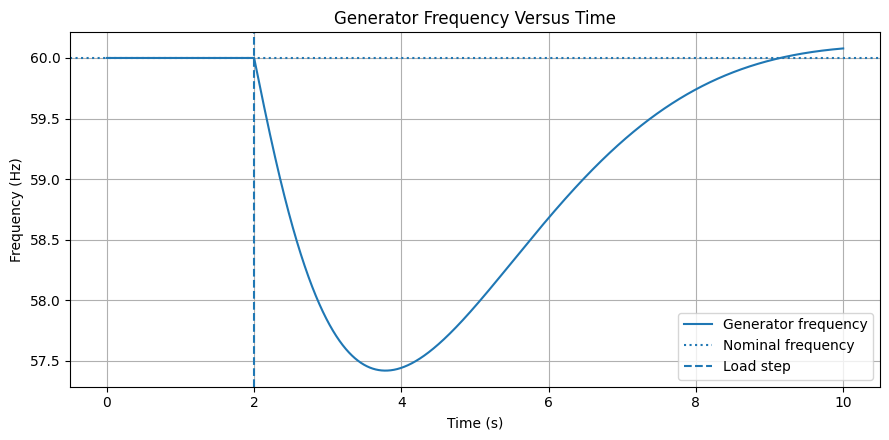

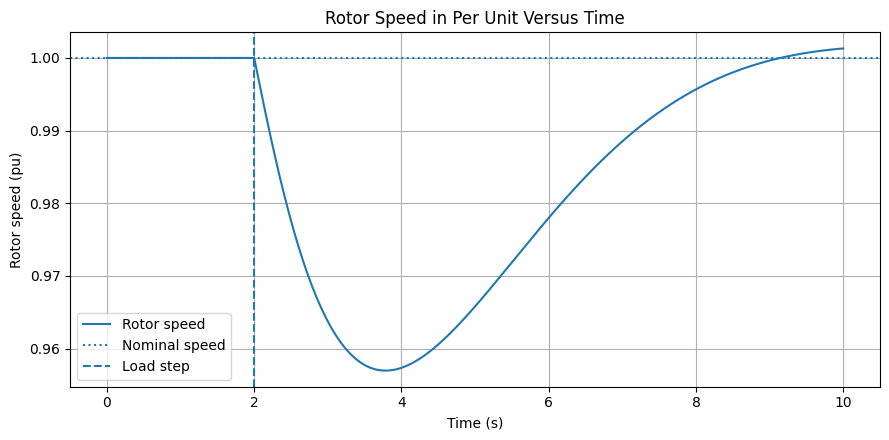

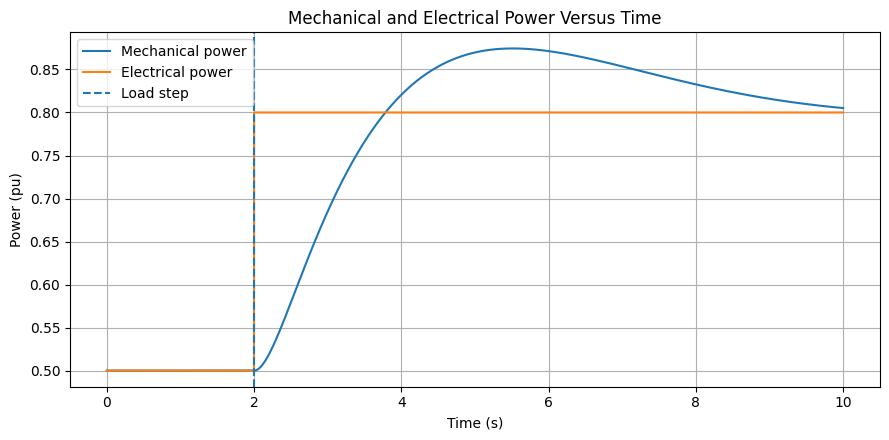

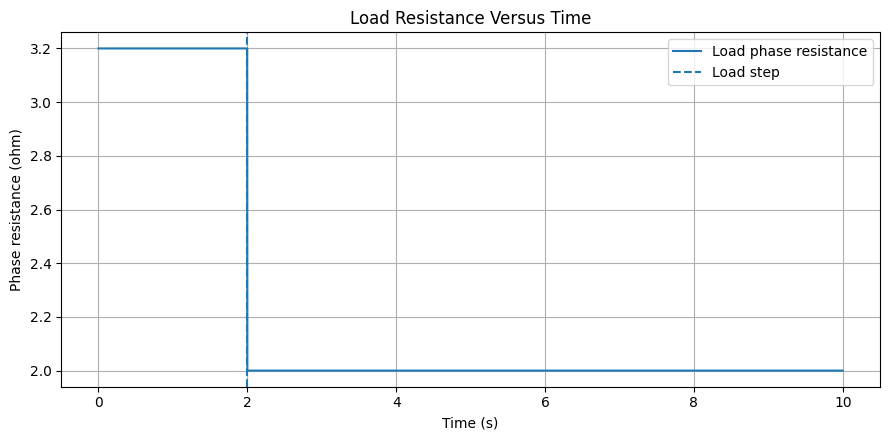

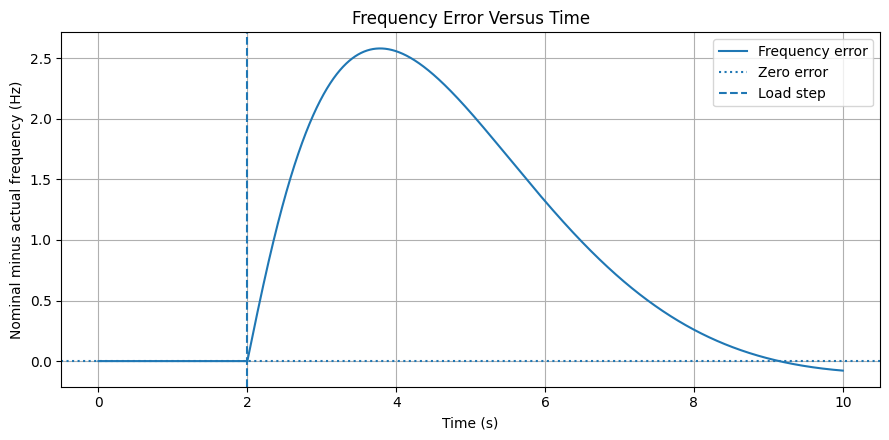

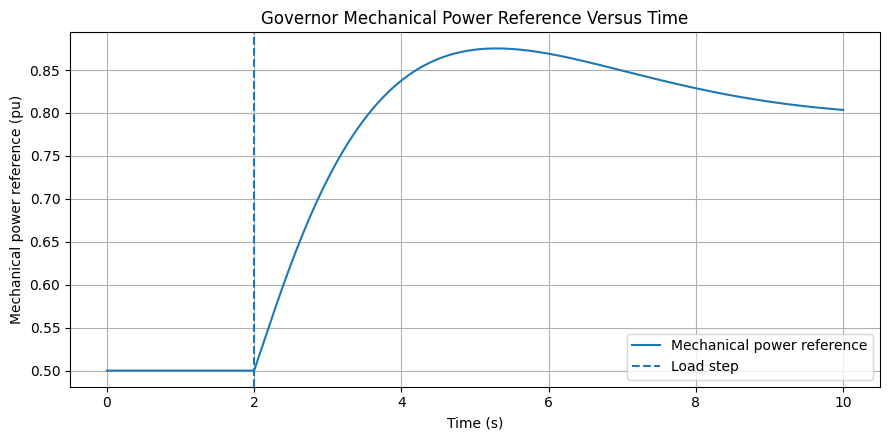

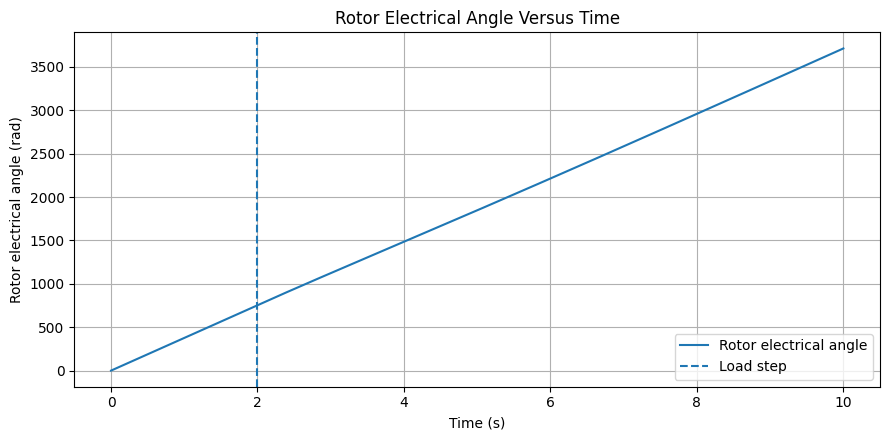

In [11]:
plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.frequency_hz, label="Generator frequency")
plt.axhline(config.F_NOM_HZ, linestyle=":", label="Nominal frequency")
add_load_step_marker()
finish_time_plot(
    "Generator Frequency Versus Time",
    "Time (s)",
    "Frequency (Hz)",
    "01_generator_frequency.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.omega_pu, label="Rotor speed")
plt.axhline(1.0, linestyle=":", label="Nominal speed")
add_load_step_marker()
finish_time_plot(
    "Rotor Speed in Per Unit Versus Time",
    "Time (s)",
    "Rotor speed (pu)",
    "02_rotor_speed_pu.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.mechanical_power_pu, label="Mechanical power")
plt.plot(pi_results.time_s, pi_results.electrical_power_pu, label="Electrical power")
add_load_step_marker()
finish_time_plot(
    "Mechanical and Electrical Power Versus Time",
    "Time (s)",
    "Power (pu)",
    "03_mechanical_and_electrical_power.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.load_resistance_ohm, label="Load phase resistance")
add_load_step_marker()
finish_time_plot(
    "Load Resistance Versus Time",
    "Time (s)",
    "Phase resistance (ohm)",
    "04_load_resistance.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.frequency_error_hz, label="Frequency error")
plt.axhline(0.0, linestyle=":", label="Zero error")
add_load_step_marker()
finish_time_plot(
    "Frequency Error Versus Time",
    "Time (s)",
    "Nominal minus actual frequency (Hz)",
    "05_frequency_error.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(
    pi_results.time_s,
    pi_results.mechanical_power_reference_pu,
    label="Mechanical power reference",
)
add_load_step_marker()
finish_time_plot(
    "Governor Mechanical Power Reference Versus Time",
    "Time (s)",
    "Mechanical power reference (pu)",
    "06_governor_power_reference.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.rotor_angle_rad, label="Rotor electrical angle")
add_load_step_marker()
finish_time_plot(
    "Rotor Electrical Angle Versus Time",
    "Time (s)",
    "Rotor electrical angle (rad)",
    "07_rotor_angle.png",
)

## Three-Phase Waveform Plots

The balanced phase voltages are displaced by 120 degrees. Since the load is purely resistive, each phase current is in phase with its corresponding phase voltage. The total instantaneous three-phase power stays nearly constant for each resistance value.

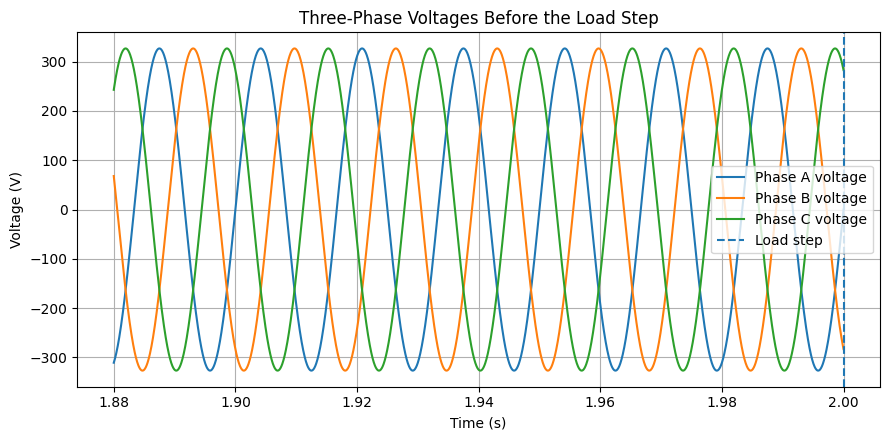

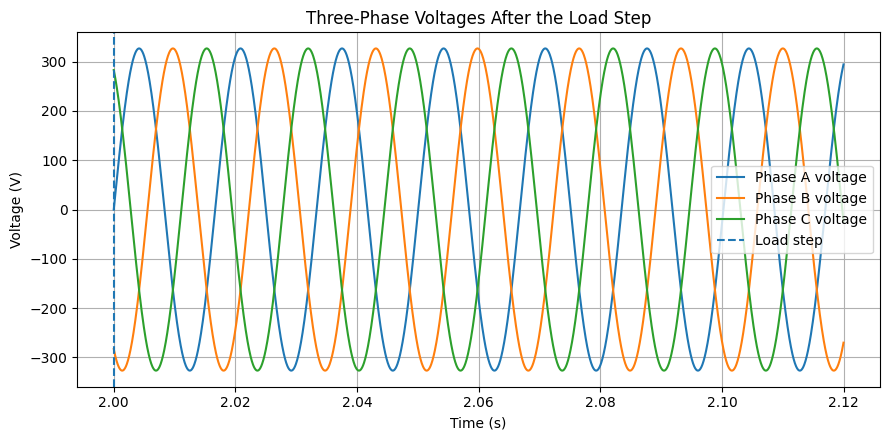

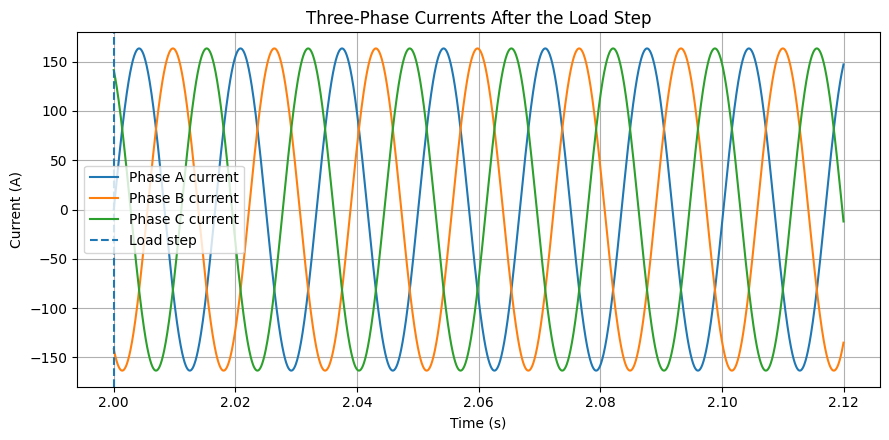

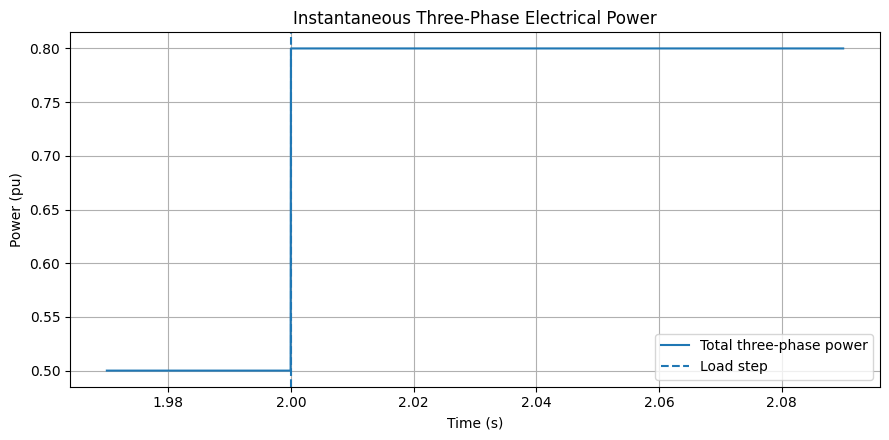

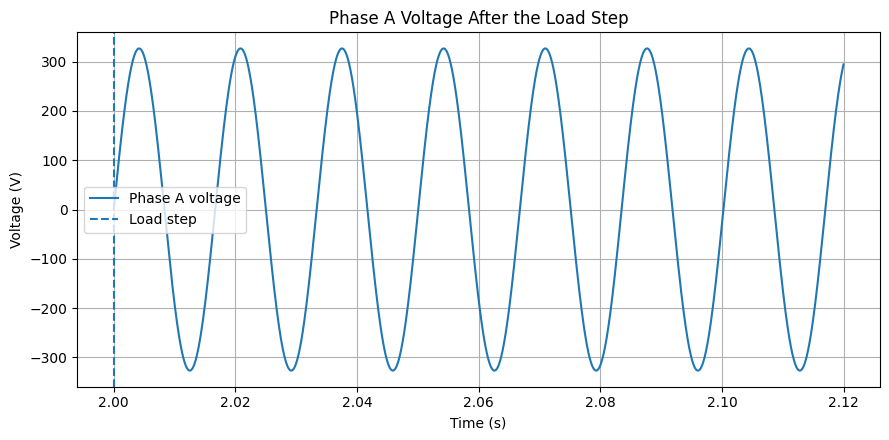

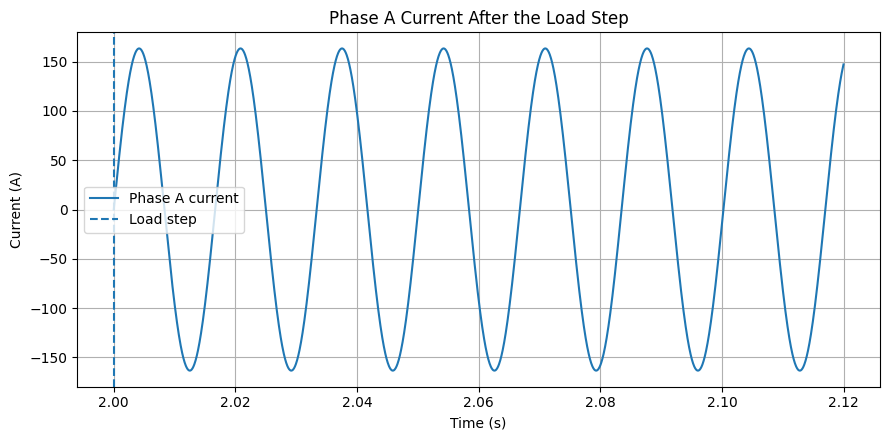

In [12]:
plt.figure(figsize=(9.0, 4.5))
plt.plot(waveforms_before["time_s"], waveforms_before["voltage_a_v"], label="Phase A voltage")
plt.plot(waveforms_before["time_s"], waveforms_before["voltage_b_v"], label="Phase B voltage")
plt.plot(waveforms_before["time_s"], waveforms_before["voltage_c_v"], label="Phase C voltage")
add_load_step_marker()
finish_time_plot(
    "Three-Phase Voltages Before the Load Step",
    "Time (s)",
    "Voltage (V)",
    "08_three_phase_voltages_before_step.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(waveforms_after["time_s"], waveforms_after["voltage_a_v"], label="Phase A voltage")
plt.plot(waveforms_after["time_s"], waveforms_after["voltage_b_v"], label="Phase B voltage")
plt.plot(waveforms_after["time_s"], waveforms_after["voltage_c_v"], label="Phase C voltage")
add_load_step_marker()
finish_time_plot(
    "Three-Phase Voltages After the Load Step",
    "Time (s)",
    "Voltage (V)",
    "09_three_phase_voltages_after_step.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(waveforms_after["time_s"], waveforms_after["current_a_a"], label="Phase A current")
plt.plot(waveforms_after["time_s"], waveforms_after["current_b_a"], label="Phase B current")
plt.plot(waveforms_after["time_s"], waveforms_after["current_c_a"], label="Phase C current")
add_load_step_marker()
finish_time_plot(
    "Three-Phase Currents After the Load Step",
    "Time (s)",
    "Current (A)",
    "10_three_phase_currents_after_step.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(waveforms_power["time_s"], waveforms_power["total_power_pu"], label="Total three-phase power")
add_load_step_marker()
finish_time_plot(
    "Instantaneous Three-Phase Electrical Power",
    "Time (s)",
    "Power (pu)",
    "11_instantaneous_three_phase_power.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(waveforms_after["time_s"], waveforms_after["voltage_a_v"], label="Phase A voltage")
add_load_step_marker()
finish_time_plot(
    "Phase A Voltage After the Load Step",
    "Time (s)",
    "Voltage (V)",
    "12_phase_a_voltage_after_step.png",
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(waveforms_after["time_s"], waveforms_after["current_a_a"], label="Phase A current")
add_load_step_marker()
finish_time_plot(
    "Phase A Current After the Load Step",
    "Time (s)",
    "Current (A)",
    "13_phase_a_current_after_step.png",
)

## Automatic Validation Checks

These checks confirm that the initial state is steady, the disturbance has the expected sign, the governor acts in the right direction, the balanced three-phase waveform is consistent, and the simplified power balance has the expected behavior.

In [13]:
def classify_check(pass_condition: bool, warning_condition: bool = False) -> str:
    """Return a PASS, WARNING, or FAIL status string."""
    if pass_condition:
        return "PASS"
    if warning_condition:
        return "WARNING"
    return "FAIL"


def estimate_phase_displacement_degrees(reference_v: FloatArray, shifted_v: FloatArray) -> float:
    """Estimate phase displacement using normalized waveform correlation."""
    centered_reference = reference_v - np.mean(reference_v)
    centered_shifted = shifted_v - np.mean(shifted_v)
    correlation = np.dot(centered_reference, centered_shifted) / (
        np.linalg.norm(centered_reference) * np.linalg.norm(centered_shifted)
    )
    bounded_correlation = float(np.clip(correlation, -1.0, 1.0))
    return math.degrees(math.acos(bounded_correlation))


def build_validation_report(
    results: SimulationResults,
    waveform_window: pd.DataFrame,
) -> pd.DataFrame:
    """Run automatic validation checks and return a concise report."""
    frequency_hz = results.frequency_hz
    step_index = int(np.searchsorted(results.time_s, results.config.LOAD_STEP_TIME_S))
    after_step_index = int(np.searchsorted(results.time_s, results.config.LOAD_STEP_TIME_S + 0.20))
    sign_index = int(np.searchsorted(results.time_s, results.config.LOAD_STEP_TIME_S + 0.02))

    initial_frequency_error_hz = abs(float(frequency_hz[0] - results.config.F_NOM_HZ))
    initial_power_error_pu = abs(
        float(results.mechanical_power_pu[0] - results.electrical_power_pu[0])
    )
    frequency_drop_hz = float(frequency_hz[after_step_index] - frequency_hz[step_index])
    mechanical_power_increase_pu = float(
        results.mechanical_power_pu[-1] - results.mechanical_power_pu[0]
    )
    final_frequency_error_hz = abs(float(frequency_hz[-1] - results.config.F_NOM_HZ))

    phase_ab_degrees = estimate_phase_displacement_degrees(
        waveform_window["voltage_a_v"].to_numpy(dtype=float),
        waveform_window["voltage_b_v"].to_numpy(dtype=float),
    )
    phase_ac_degrees = estimate_phase_displacement_degrees(
        waveform_window["voltage_a_v"].to_numpy(dtype=float),
        waveform_window["voltage_c_v"].to_numpy(dtype=float),
    )
    maximum_phase_error_degrees = max(
        abs(phase_ab_degrees - 120.0),
        abs(phase_ac_degrees - 120.0),
    )

    power_mean_w = float(waveform_window["total_power_w"].mean())
    power_std_w = float(waveform_window["total_power_w"].std())
    relative_power_std = power_std_w / abs(power_mean_w)

    power_imbalance_pu = float(
        results.mechanical_power_pu[sign_index] - results.electrical_power_pu[sign_index]
    )
    measured_speed_derivative_pu_per_s = float(
        (results.omega_pu[sign_index + 1] - results.omega_pu[sign_index - 1])
        / (results.time_s[sign_index + 1] - results.time_s[sign_index - 1])
    )
    sign_consistent = power_imbalance_pu < 0.0 and measured_speed_derivative_pu_per_s < 0.0

    report_rows = [
        {
            "status": classify_check(initial_frequency_error_hz <= 1e-9),
            "check": "Initial frequency is approximately 60 Hz",
            "value": initial_frequency_error_hz,
            "unit": "Hz error",
        },
        {
            "status": classify_check(initial_power_error_pu <= 1e-9),
            "check": "Initial mechanical and electrical powers are equal",
            "value": initial_power_error_pu,
            "unit": "pu error",
        },
        {
            "status": classify_check(frequency_drop_hz < -0.01),
            "check": "Frequency initially decreases after the load increase",
            "value": frequency_drop_hz,
            "unit": "Hz change",
        },
        {
            "status": classify_check(mechanical_power_increase_pu > 0.20),
            "check": "Mechanical power increases after the disturbance",
            "value": mechanical_power_increase_pu,
            "unit": "pu increase",
        },
        {
            "status": classify_check(
                final_frequency_error_hz <= 0.10,
                warning_condition=final_frequency_error_hz <= 0.50,
            ),
            "check": "Final frequency returns close to 60 Hz",
            "value": final_frequency_error_hz,
            "unit": "Hz error",
        },
        {
            "status": classify_check(maximum_phase_error_degrees <= 1.0),
            "check": "Three phase voltages are displaced by approximately 120 degrees",
            "value": maximum_phase_error_degrees,
            "unit": "degree error",
        },
        {
            "status": classify_check(relative_power_std <= 1e-10, warning_condition=relative_power_std <= 1e-8),
            "check": "Total instantaneous power is approximately constant for a balanced resistive load",
            "value": relative_power_std,
            "unit": "relative standard deviation",
        },
        {
            "status": classify_check(sign_consistent),
            "check": "Energy and power signs are consistent immediately after the disturbance",
            "value": measured_speed_derivative_pu_per_s,
            "unit": "pu/s speed derivative",
        },
    ]
    return pd.DataFrame(report_rows)


validation_report = build_validation_report(pi_results, waveforms_after)

for _, row in validation_report.iterrows():
    print(f"{row['status']}: {row['check']} ({row['value']:.6g} {row['unit']})")

validation_report

PASS: Initial frequency is approximately 60 Hz (0 Hz error)
PASS: Initial mechanical and electrical powers are equal (0 pu error)
PASS: Frequency initially decreases after the load increase (-0.586615 Hz change)
PASS: Mechanical power increases after the disturbance (0.305124 pu increase)
PASS: Final frequency returns close to 60 Hz (0.0786343 Hz error)
PASS: Three phase voltages are displaced by approximately 120 degrees (0.973744 degree error)
PASS: Total instantaneous power is approximately constant for a balanced resistive load (2.89447e-16 relative standard deviation)
PASS: Energy and power signs are consistent immediately after the disturbance (-0.0499595 pu/s speed derivative)


,status,check,value,unit
0,PASS,Initial frequency is approximately 60 Hz,0.000000e+00,Hz error
1,PASS,Initial mechanical and electrical powers are e...,0.000000e+00,pu error
2,PASS,Frequency initially decreases after the load i...,-5.866150e-01,Hz change
3,PASS,Mechanical power increases after the disturbance,3.051241e-01,pu increase
4,PASS,Final frequency returns close to 60 Hz,7.863431e-02,Hz error
5,PASS,Three phase voltages are displaced by approxim...,9.737443e-01,degree error
6,PASS,Total instantaneous power is approximately con...,2.894471e-16,relative standard deviation
7,PASS,Energy and power signs are consistent immediat...,-4.995946e-02,pu/s speed derivative


## Proportional-Only Versus PI Control

A proportional-only governor increases mechanical power when frequency drops, but in this simplified isolated system it generally needs a nonzero speed error to sustain the new mechanical power level. Integral action accumulates the speed error and shifts the mechanical power reference until the steady-state frequency error is eliminated.

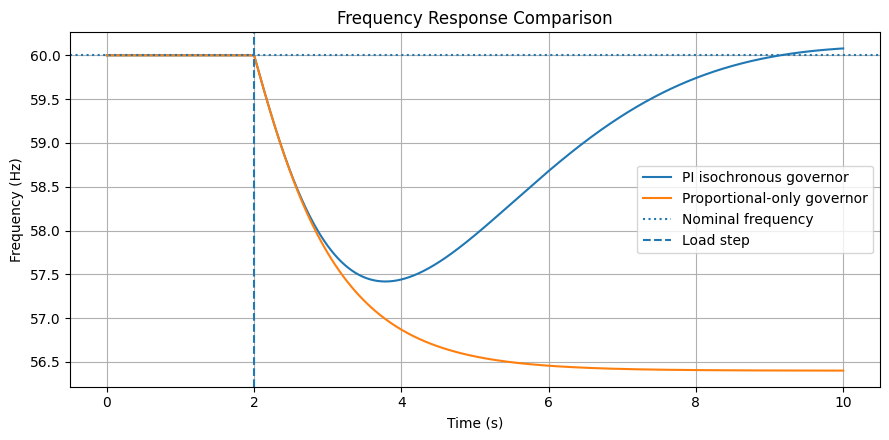

,case,minimum_frequency_hz,final_frequency_hz,settling_time_s,steady_state_error_hz
0,PI isochronous governor,57.418273,60.078634,Not reached in simulation window,-0.078634
1,Proportional-only governor,56.400827,56.400827,Not reached in simulation window,3.599173


In [14]:
proportional_config = replace(config, KI=0.0)
proportional_simulation = DynamicSimulation(proportional_config)
proportional_results = proportional_simulation.run()


def comparison_metrics(label: str, results: SimulationResults) -> dict[str, float | str]:
    """Calculate comparison metrics for one governor case."""
    minimum_frequency_hz = float(np.min(results.frequency_hz))
    final_frequency_hz = float(results.frequency_hz[-1])
    settling_time_s = calculate_settling_time(results)
    steady_state_error_hz = float(results.config.F_NOM_HZ - final_frequency_hz)
    return {
        "case": label,
        "minimum_frequency_hz": minimum_frequency_hz,
        "final_frequency_hz": final_frequency_hz,
        "settling_time_s": format_metric_value(settling_time_s),
        "steady_state_error_hz": steady_state_error_hz,
    }


comparison_table = pd.DataFrame(
    [
        comparison_metrics("PI isochronous governor", pi_results),
        comparison_metrics("Proportional-only governor", proportional_results),
    ]
)

plt.figure(figsize=(9.0, 4.5))
plt.plot(pi_results.time_s, pi_results.frequency_hz, label="PI isochronous governor")
plt.plot(
    proportional_results.time_s,
    proportional_results.frequency_hz,
    label="Proportional-only governor",
)
plt.axhline(config.F_NOM_HZ, linestyle=":", label="Nominal frequency")
add_load_step_marker()
finish_time_plot(
    "Frequency Response Comparison",
    "Time (s)",
    "Frequency (Hz)",
    "14_frequency_response_comparison.png",
)

comparison_table

## Model Limitations

This simplified model is intended to study the basic active-power and frequency balance of an isolated generator. It does not include:

- synchronous reactance
- stator electromagnetic transients
- field-winding dynamics
- excitation-system dynamics
- magnetic saturation
- saliency
- subtransient and transient reactances
- detailed dq-axis equations
- voltage drop caused by internal impedance
- unbalanced-load effects
- shaft torsional dynamics

The constant-voltage assumption is useful for teaching the link between active power, mechanical torque, inertia, and frequency, but it is not a substitute for a detailed synchronous-machine transient model.

## Save Numerical Results

The dynamic time-series results, scalar summary table, governor comparison table, and validation report are saved in the `results` directory. Figures have already been saved as PNG files in `results/figures`.

In [15]:
dynamic_results_path = RESULTS_DIR / "dynamic_generator_results.csv"
summary_results_path = RESULTS_DIR / "dynamic_generator_summary.csv"
comparison_results_path = RESULTS_DIR / "governor_comparison.csv"
validation_results_path = RESULTS_DIR / "validation_report.csv"

results_df.to_csv(dynamic_results_path, index=False)
summary_table.to_csv(summary_results_path, index=False)
comparison_table.to_csv(comparison_results_path, index=False)
validation_report.to_csv(validation_results_path, index=False)

print(f"Saved dynamic time-series results to: {dynamic_results_path}")
print(f"Saved summary results to: {summary_results_path}")
print(f"Saved governor comparison to: {comparison_results_path}")
print(f"Saved validation report to: {validation_results_path}")
print(f"Saved {len(saved_figure_paths)} figures to: {FIGURES_DIR}")

Saved dynamic time-series results to: results\dynamic_generator_results.csv
Saved summary results to: results\dynamic_generator_summary.csv
Saved governor comparison to: results\governor_comparison.csv
Saved validation report to: results\validation_report.csv
Saved 14 figures to: results\figures


## Conclusions

The simulation demonstrates the active-power and frequency balance of an isolated generator:

- frequency is directly linked to rotor speed
- a load increase creates a temporary active-power imbalance
- inertia limits the initial rate of frequency change
- the governor restores mechanical power balance through the prime mover
- integral control eliminates steady-state frequency error in the simplified model
- balanced three-phase resistive loads simplify the electrical-power calculation because total instantaneous three-phase power is nearly constant

The proportional-only comparison shows why an isochronous PI governor is important when the operating goal is to return frequency to the nominal value rather than accept a permanent speed offset.